In [1]:
import hoda
import tensorly as tl
tl.get_backend()
import cupyx
cupyx.seterr(linalg='raise')

{'divide': None,
 'over': None,
 'under': None,
 'invalid': None,
 'linalg': 'ignore',
 'fallback_mode': 'ignore'}

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abb

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_607/2075018065.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 26)

In [16]:
from hoda.hoda import BTTDA, HODA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

bttda = BTTDA(
    max_blocks=16,
    info_crit='bic',
    hoda_params=dict(
        rank=None,
        max_iter=256,
        tol=1e-12,
        init ='mlsvd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lanczos',
        taper=False,
        keep_train_info=False,
        verbose=True,
    ),
    verbose=True,
    keep_train_info=True,
)

bttda.fit(X,y)

Fitting block 1/16...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
Initializing factors...
Fitting discriminative Tucker model...


...

  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
((2, 2), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (3, 3), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2), (1, 1), (2, 2), (1, 1))


BTTDA(hoda_params={'init': 'mlsvd', 'keep_train_info': False, 'max_iter': 256,
                   'obj': 'rt', 'rank': 2, 'shrinkage': 'lw',
                   'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                   'tol': 1e-12, 'verbose': True},
      keep_train_info=True, max_blocks=16, verbose=True)

In [6]:
import ipdb
#ipdb.pm()

> /usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py(2436)run_line_magic()
   2435                                     'did you mean that instead?)' % magic_name )
-> 2436             raise UsageError(etpl % (magic_name, extra))
   2437         else:



ipdb>  q


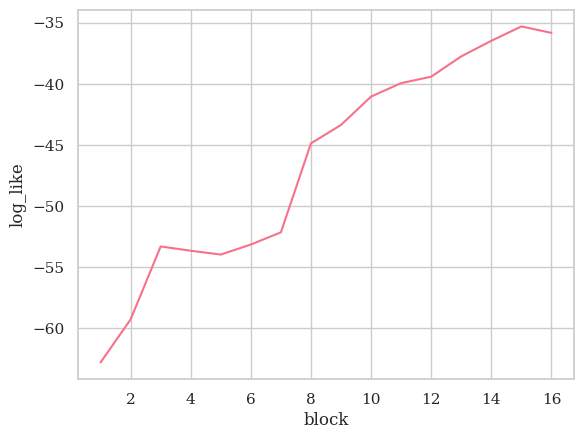

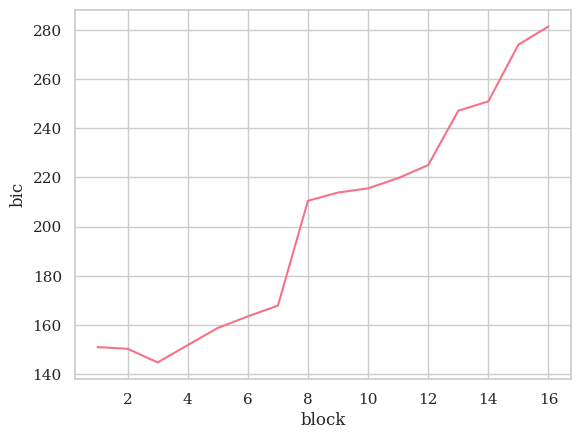

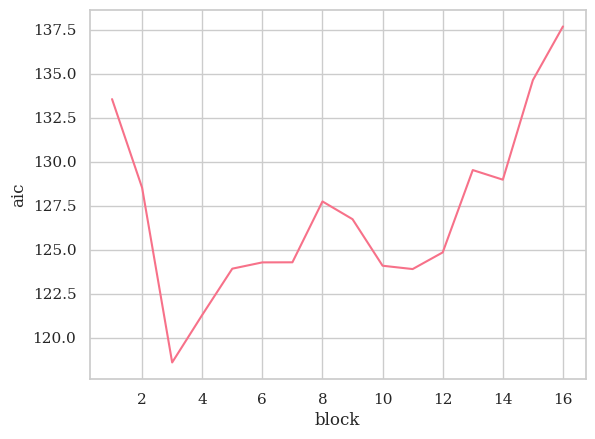

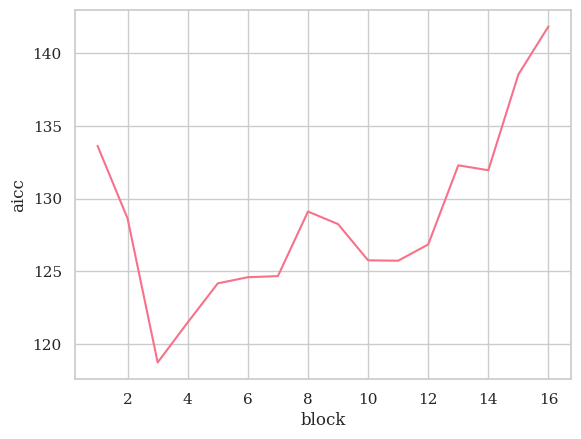

<Axes: xlabel='block', ylabel='mse'>

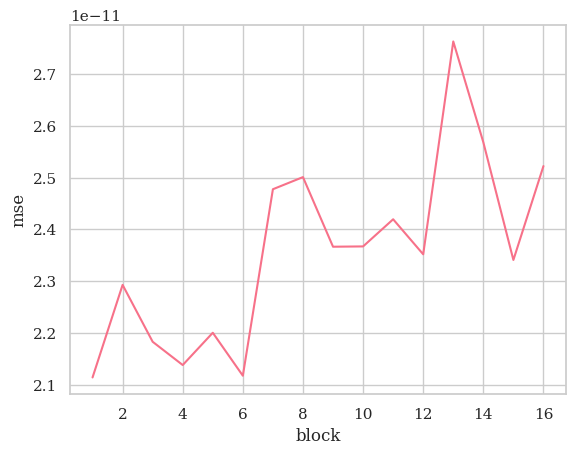

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from hoda.hoda import log_likelihood, aic
n_samples = X.shape[0]
sns.lineplot(data=bttda.train_info_, x='block', y='log_like')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='bic')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='aic')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='aicc')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='mse')

In [8]:
Xt = bttda.transform(X)

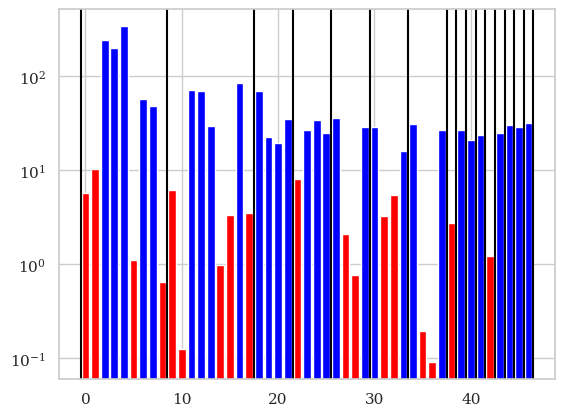

In [9]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b in bttda.blocks_:
    n_params+=math.prod(b.ml_rank_)
    plt.axvline(n_params-.5, color='black')


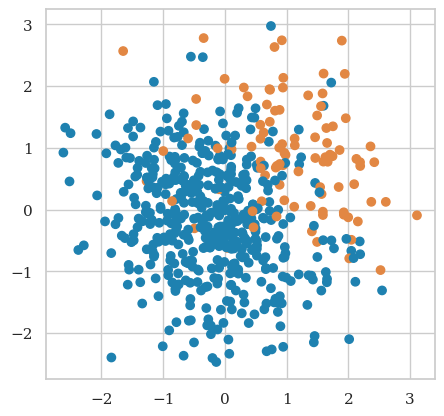

In [10]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [11]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


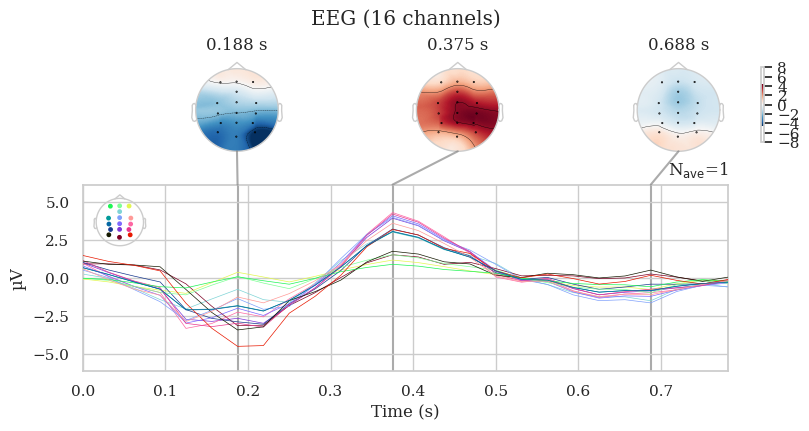

No projector specified for this dataset. Please consider the method self.add_proj.


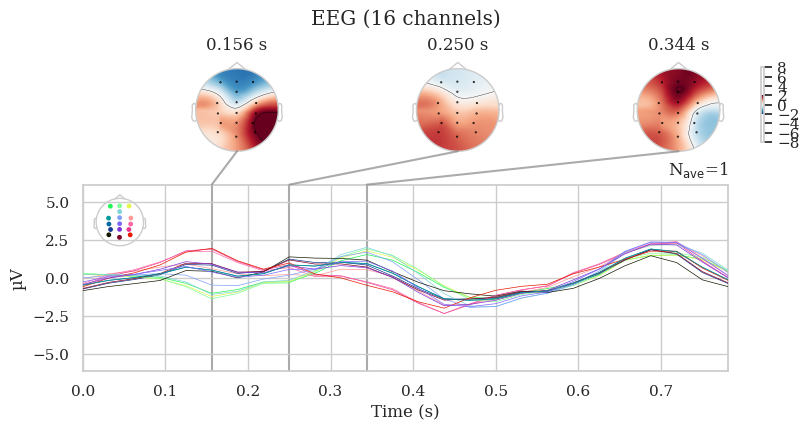

No projector specified for this dataset. Please consider the method self.add_proj.


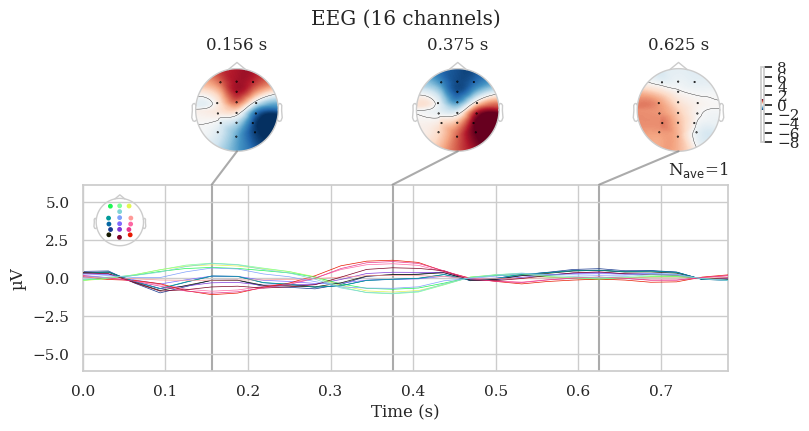

No projector specified for this dataset. Please consider the method self.add_proj.


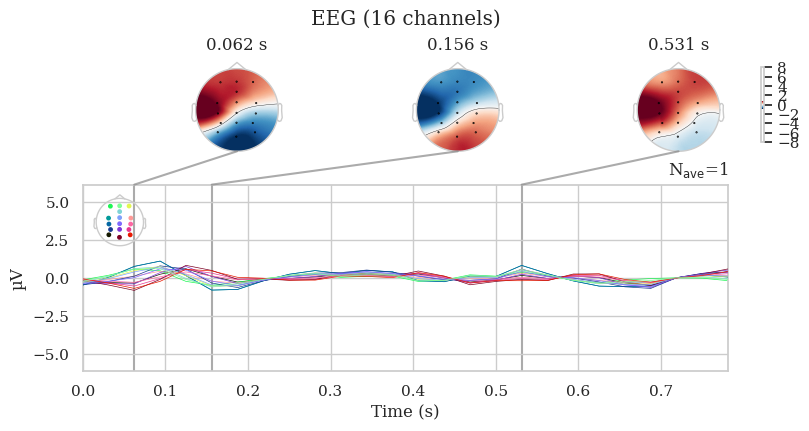

No projector specified for this dataset. Please consider the method self.add_proj.


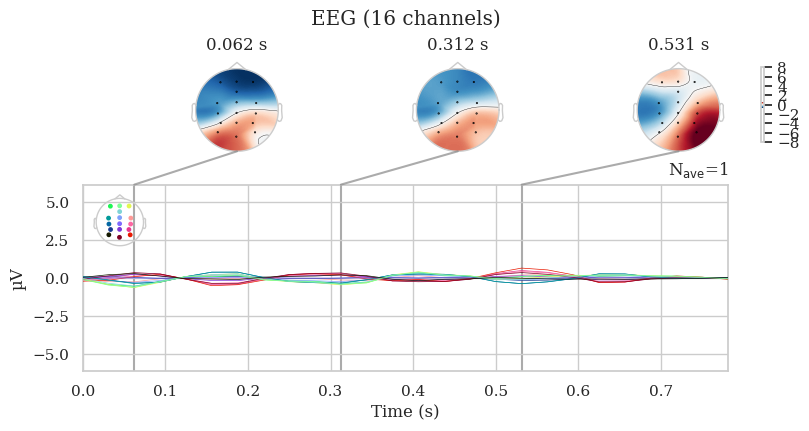

No projector specified for this dataset. Please consider the method self.add_proj.


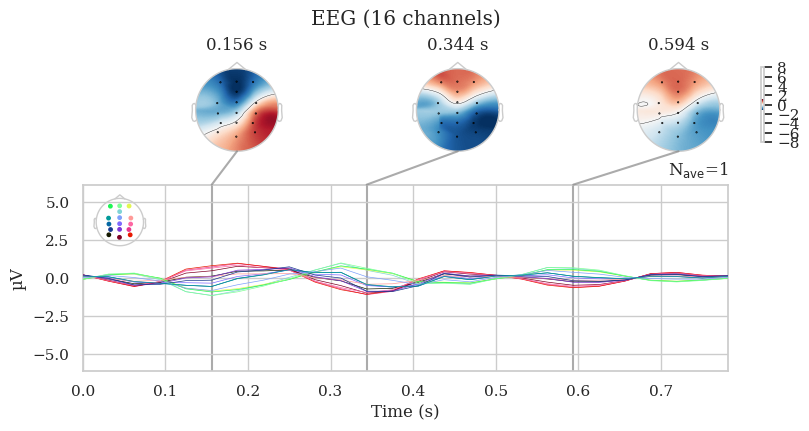

No projector specified for this dataset. Please consider the method self.add_proj.


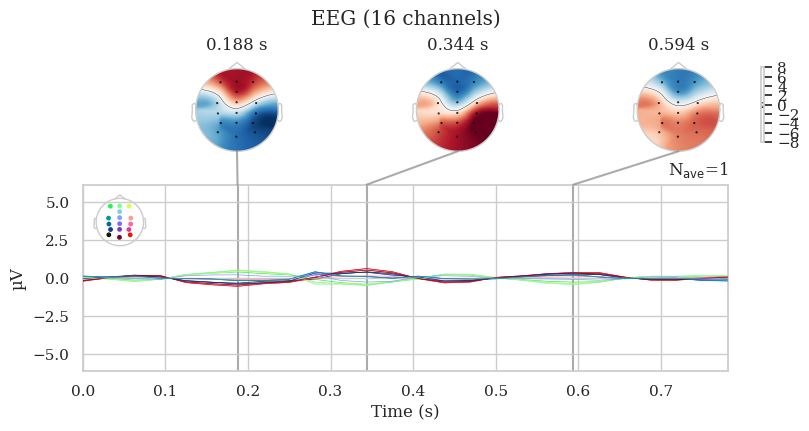

No projector specified for this dataset. Please consider the method self.add_proj.


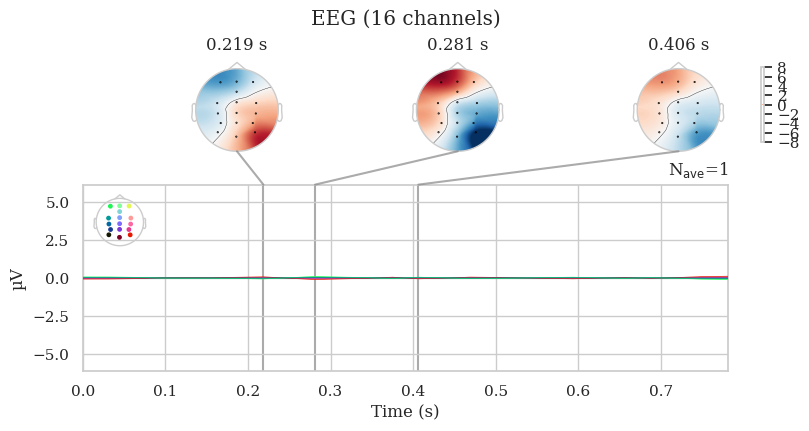

No projector specified for this dataset. Please consider the method self.add_proj.


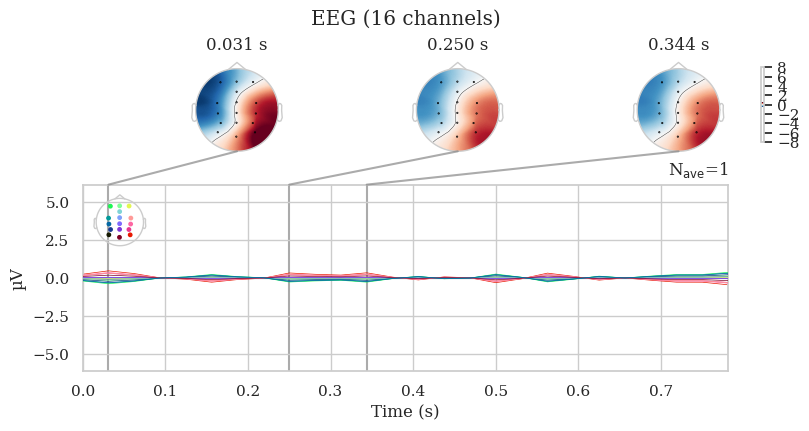

No projector specified for this dataset. Please consider the method self.add_proj.


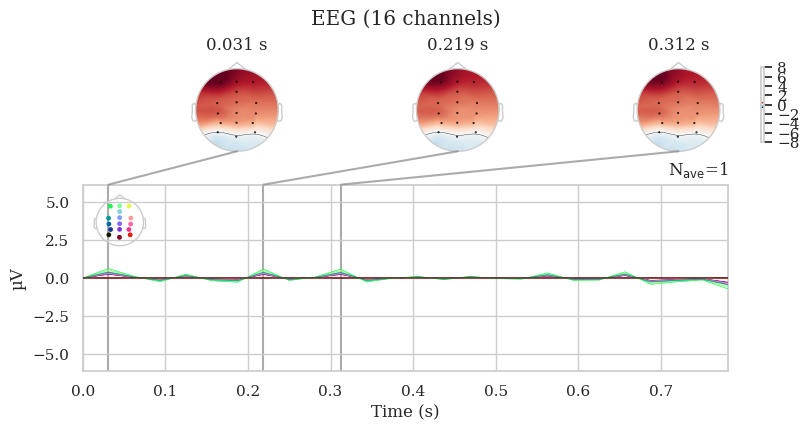

No projector specified for this dataset. Please consider the method self.add_proj.


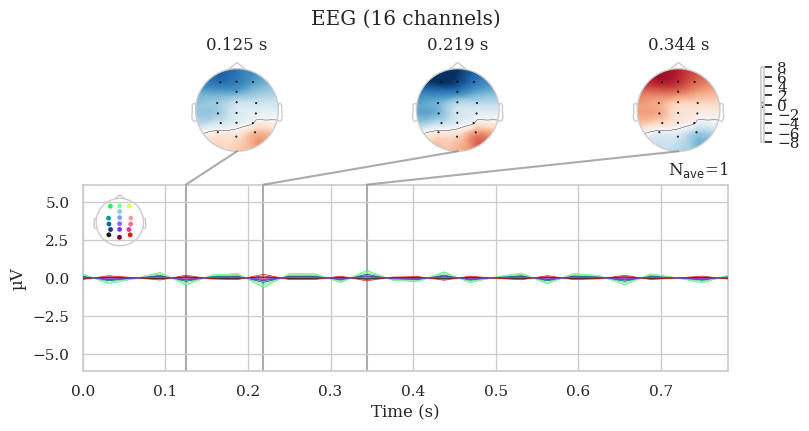

No projector specified for this dataset. Please consider the method self.add_proj.


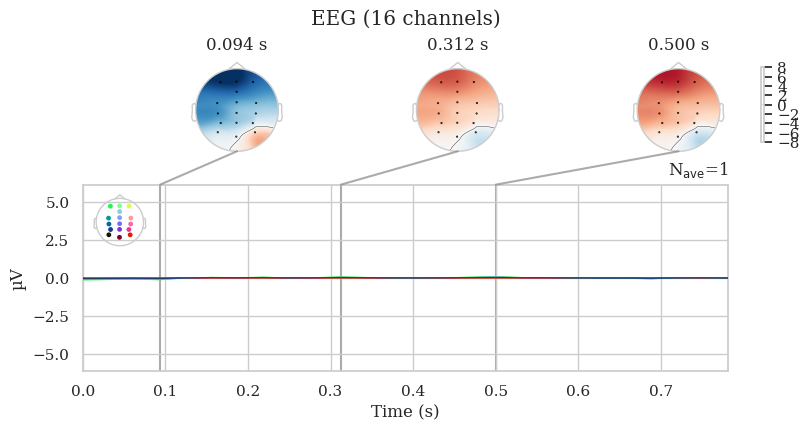

No projector specified for this dataset. Please consider the method self.add_proj.


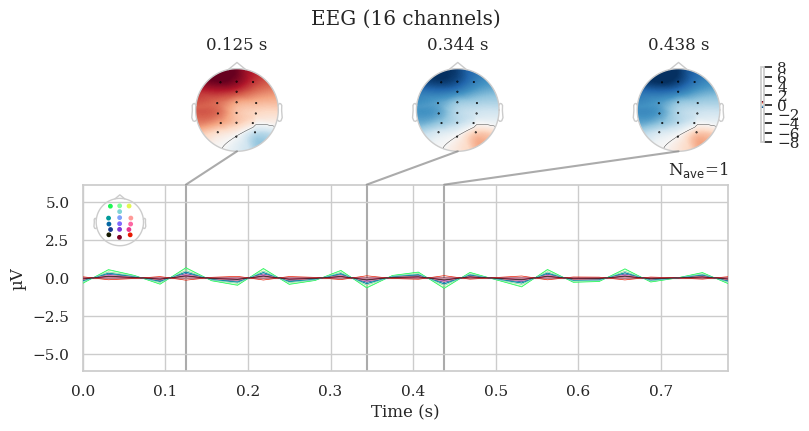

No projector specified for this dataset. Please consider the method self.add_proj.


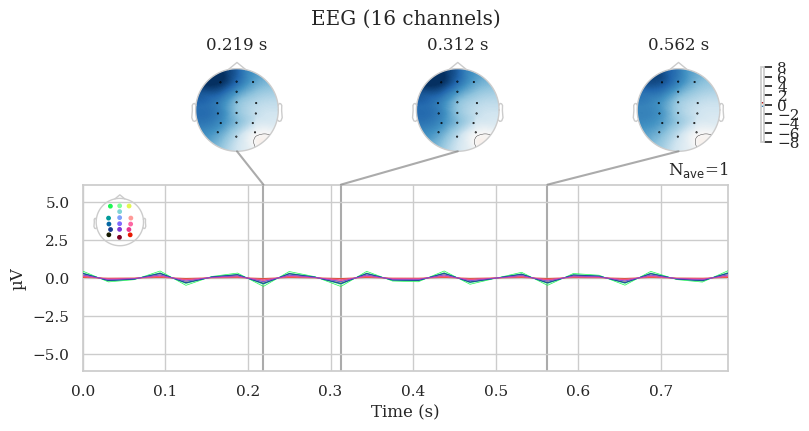

No projector specified for this dataset. Please consider the method self.add_proj.


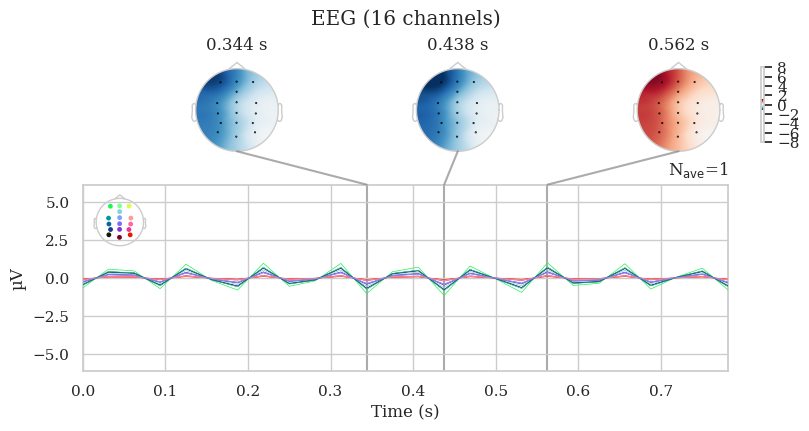

No projector specified for this dataset. Please consider the method self.add_proj.


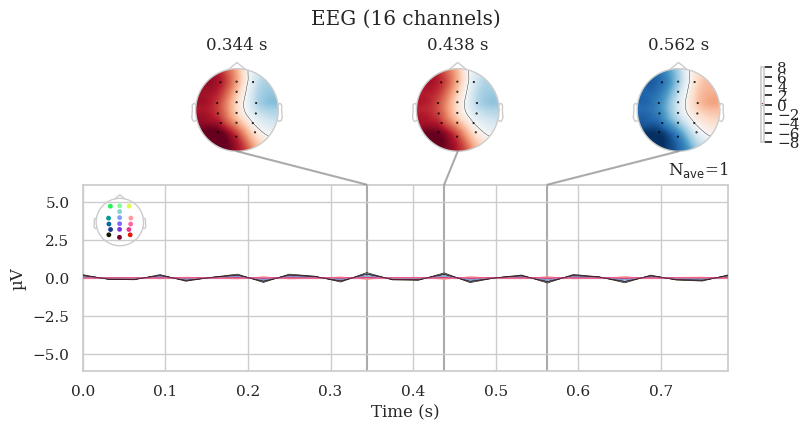

In [12]:
from mne import EvokedArray
for b in bttda.blocks_:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [13]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


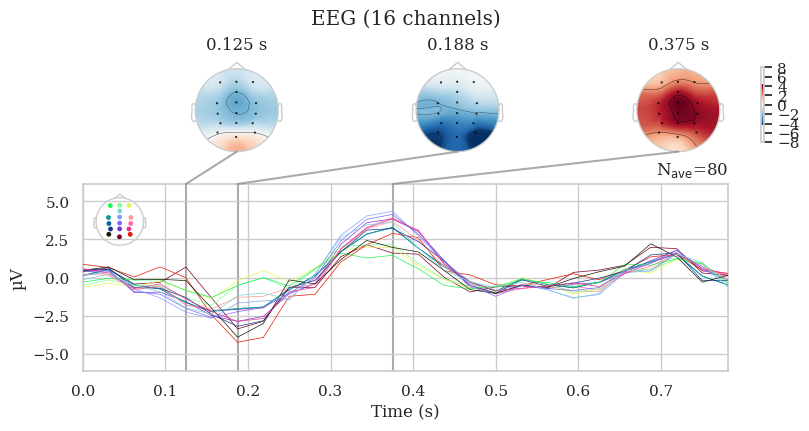

No projector specified for this dataset. Please consider the method self.add_proj.


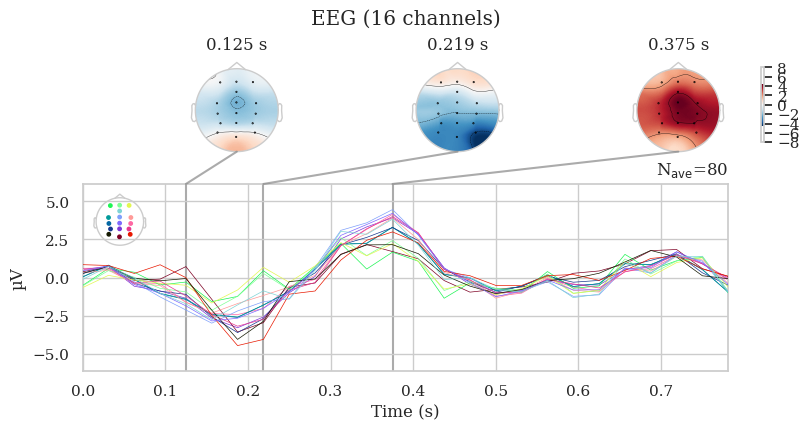

In [14]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


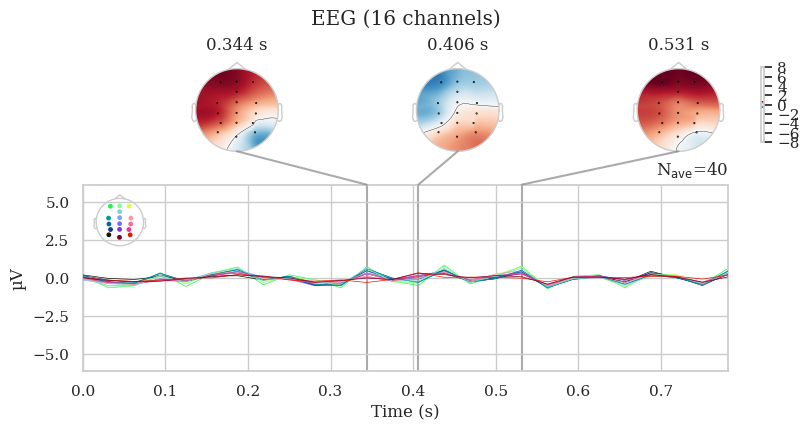

In [15]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)